Decoder

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import copy
from collections.abc import Callable

def attention(query, key, value, mask=None, dropout=None):
    """Scaled Dot-Product Attention
                     ▲
        ┌────────────┴─────────────┐
        │4) MatMul                 │ ← Attention Weights · V
        └────▲──────────────────▲──┘
        ┌────┴──────┐           │  
        │3) Softmax │           │
        └────▲──────┘           │
       ┌─────┴────────┐         │
       │2) Mask (opt.)│         │
       └─────▲────────┘         │
        ┌────┴──────┐           │
        │1) Scale   │ (/ √d_k)  │
        └────▲──────┘           │
        ┌────┴──────┐           │
        │1) MatMul  │ ← Q · Kᵀ  │
        └────▲──────┘           │
       ┌─────┴─────┐────────────│ 
       Q           K            V
    """
    print(f"+AT: q/k/v shapes: {query.shape}")
    d_k = query.size(-1)
    # input: query, key, value shape: (batch_size, h, seq_len, d_k)
    #
    # 1) MatMul(QK^T) + Scale(math.sqrt(d_k)) (scaled dot-product):
    #    (batch_size, h, seq_len, d_k) - > (batch_size, h, seq_len, seq_len)
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)
    #
    # 2) Mask optional for decoder
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
    print(f"\tscores shape: {scores.shape}")
    #
    # 3) softmax (batch_size, h, seq_len, seq_len) -> (batch_size, h, seq_len, seq_len)
    attn = F.softmax(scores, dim=-1)
    print(f"\tattn shape: {scores.shape}")
    if dropout is not None:
        attn = dropout(attn)
    #
    # 4) MatMul(AV) (batch_size, h, seq_len, seq_len) * (batch_size, h, seq_len, d_k) -> (batch_size, h, seq_len, d_k)
    #    (d_v == d_k == d_model // h)
    out = torch.matmul(attn, value)    
    print(f"-AT: output shape:{out.shape}")
    return out, attn

class MultiHeadAttention(nn.Module):
    """Multi-head attention: d_model dimensional, h heads
                           ┌─────────┐
                           │ Linear  │
                           └────▲────┘
                                │
                           ┌────┴────┐
                           │ Concat  │
                           └────▲────┘
                                │
        ┌─────────────────────────────────────────┐
        │     Scaled Dot-Product Attention        │   × h
        └─────────────────────────────────────────┘
             ▲                ▲                ▲
             │                │                │
         ┌───┴───┐        ┌───┴───┐        ┌───┴───┐
         │ Linear│        │ Linear│        │ Linear│
         └───▲───┘        └───▲───┘        └───▲───┘
             │                │                │
             V                K                Q
    """
    def __init__(self, d_model, h, dropout=0.1):
        super(MultiHeadAttention, self).__init__()
        assert d_model % h == 0
        self.h = h
        self.d_k = d_model // h
        # 4 linear layers: Q, K, V projections + output projection
        self.linears = nn.ModuleList([nn.Linear(in_features=d_model, out_features=d_model) for _ in range(4)])
        self.dropout = nn.Dropout(p=dropout)
        # store the probability score for visualization
        self.attn = None
    
    def forward(self, query, key, value, mask=None):
        print(f"+MHA:{list(query.shape)}")
        # query, key, value shape (batch_size, seq_len, d_model)
        batch_size = query.size(0)
        # 1) Linear projections
        #    q_p, k_p, v_p shape (batch_size, h, seq_len, d_k)
        q_p, k_p, v_p = [l(x).view(batch_size, -1, self.h, self.d_k).transpose(1, 2)
                        for l, x in zip(self.linears, (query, key, value))]
        # 2) h times attention (in parallel)
        # concat_attn shape (batch_size, h, seq_len, d_k)
        concat_attn, self.attn = attention(q_p, k_p, v_p, mask, self.dropout)
        # 3) Concat
        # reshape to (batch_size, seq_len, h, d_k)
        concat_attn = concat_attn.transpose(1, 2).contiguous().view(batch_size, -1, self.h * self.d_k)
        # concat to (batch_size, seq_len, d_model(h * d_k))
        # concat_attn = concat_attn.view(batch_size, -1, self.h * self.d_k)
        # 4) linear
        # out shape (batch_size, seq_len, d_model)
        out = self.linears[-1](concat_attn)
        print(f"-MHA: output shape:{list(out.shape)}")
        return out

class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.linear_1 = nn.Linear(in_features=d_model, out_features=d_ff) # w_1 and b_1
        self.linear_2 = nn.Linear(in_features=d_ff, out_features=d_model) # w_2 and b_2
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x):
        print(f"+FFN: x.shape:{x.shape}")
        h1 = self.linear_1(x)
        h2 = self.dropout(torch.relu(h1))
        out_ffn = self.linear_2(h2)
        print(f"-FFN:out shape:{out_ffn.shape}")
        return out_ffn

# Layer normalization
class LayerNorm(nn.Module):
    def __init__(self, features, eps=1e-6):
        super(LayerNorm, self).__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(features)) # alpha is a learnable parameter
        self.bias = nn.Parameter(torch.zeros(features)) # bias is a learnable parameter

    def forward(self, x):
        # x shape: (batch, seq_len, d_model)
        # mean shape: (batch, seq_len, 1)
        print(f"+LN x shape:{x.shape}")
        mean = x.mean(-1, keepdim=True)
        print(f"\tLN: mean shape: {mean.shape}")
        # std shape: (batch, seq_len, 1)
        std = x.std(-1, keepdim=True, unbiased=False)
        print(f"\tLN: std shape: {mean.shape}")
        output_n = self.weight * (x - mean) / (std + self.eps) + self.bias
        print(f"-LN output shape:{output_n.shape}")
        return output_n

class ResidualConnection(nn.Module):
    def __init__(self, features: int, dropout: float = 0.1):
        super(ResidualConnection, self).__init__()
        self.norm = LayerNorm(features)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, sublayer: Callable):
        print(f"+RC: x.shape={x.shape}")
        # out_rc = self.norm(x + self.dropout(sublayer(x)))
        # POST-NORM vs PRE-NORM: 
        # This implementation uses PRE-NORM (norm before sublayer)
        # but the original transform paper used POST-NORM (norm after addition):
        #     Input (x)
        #    |
        #    ├─────────────────┐
        #    |                 |
        #    |            Sublayer(x)
        #    |                 |
        #    |             Dropout
        #    |                 |
        #    └────── (+) ──────┘
        #           |
        #      LayerNorm
        #           |
        #        Output
        # LayerNorm(x + Sublayer(x))
        # out_rc = self.norm(x + self.dropout(sublayer(x)))
        #
        # Modern Implementation: Pre-Norm (LayerNorm BEFORE sublayer)
        # often works better in practice
        # x + Sublayer(LayerNorm(x))
        #
        #     Input (x)
        #    |
        #    ├─────────────────┐
        #    |                 |
        #    |            LayerNorm
        #    |                 |
        #    |            Sublayer
        #    |                 |
        #    |             Dropout
        #    |                 |
        #    └────── (+) ──────┘
        #           |
        #        Output
        #
        # ================================================================================
        # KEY DIFFERENCES
        # ================================================================================

        # Aspect                    Post-Norm (Paper)              Pre-Norm (Modern)             
        # --------------------------------------------------------------------------------
        # Normalization Position    After residual addition        Before sublayer               
        # Gradient Flow             Through normalization          Direct path via residual      
        # Training Stability        Can be unstable                More stable                   
        # Learning Rate             Needs warmup                   Less sensitive                
        # Convergence               Slower initially               Faster convergence            
        # Final Performance         Slightly better (sometimes)    Slightly worse (sometimes)    
        # Ease of Training          Harder                         Easier                        

        out_rc = x + self.dropout(sublayer(self.norm(x)))
        print(f"-RC: output shape: {out_rc.shape}")
        return out_rc
        

In [18]:
# Decoder layers: Multi-head self-attention + cross-attention + feed-forward
batch_size, seq_len,  d_model, h , d_ff, dropout = 1, 10, 512, 8, 2048, 0.1
x = torch.randn(batch_size, seq_len, d_model)

src_mask = torch.randn(batch_size, seq_len).unsqueeze(-2)
tgt_mask = None

# assume m as the encoder output for cross-attention
m = torch.randn(batch_size, seq_len, d_model)

# cross_attn = MultiHeadAttention(d_model, h)
# ffn = PositionwiseFeedForward(d_model, d_ff)
# layer_1: Self attention
layer_1 = ResidualConnection(d_model, dropout)
# self_attn = MultiHeadAttention(d_model, h)
self_attn = lambda x: MultiHeadAttention(d_model, h)(x, x, x, tgt_mask)
x = layer_1(x, self_attn)

# layer_2: Cross attention
layer_2 = ResidualConnection(d_model, dropout)
cross_attn = lambda x: MultiHeadAttention(d_model, h)(x, m, m, src_mask)
x = layer_2(x, cross_attn)

# layer_3: Feed-forward network
layer_3 = ResidualConnection(d_model, dropout)
ffn = lambda x: PositionwiseFeedForward(d_model, d_ff)(x)
x = layer_3(x, ffn)

print(f"Output shape: {x.shape}")


+RC: x.shape=torch.Size([1, 10, 512])
+LN x shape:torch.Size([1, 10, 512])
	LN: mean shape: torch.Size([1, 10, 1])
	LN: std shape: torch.Size([1, 10, 1])
-LN output shape:torch.Size([1, 10, 512])
+MHA:[1, 10, 512]
+AT: q/k/v shapes: torch.Size([1, 8, 10, 64])
	scores shape: torch.Size([1, 8, 10, 10])
	attn shape: torch.Size([1, 8, 10, 10])
-AT: output shape:torch.Size([1, 8, 10, 64])
-MHA: output shape:[1, 10, 512]
-RC: output shape: torch.Size([1, 10, 512])
+RC: x.shape=torch.Size([1, 10, 512])
+LN x shape:torch.Size([1, 10, 512])
	LN: mean shape: torch.Size([1, 10, 1])
	LN: std shape: torch.Size([1, 10, 1])
-LN output shape:torch.Size([1, 10, 512])
+MHA:[1, 10, 512]
+AT: q/k/v shapes: torch.Size([1, 8, 10, 64])
	scores shape: torch.Size([1, 8, 10, 10])
	attn shape: torch.Size([1, 8, 10, 10])
-AT: output shape:torch.Size([1, 8, 10, 64])
-MHA: output shape:[1, 10, 512]
-RC: output shape: torch.Size([1, 10, 512])
+RC: x.shape=torch.Size([1, 10, 512])
+LN x shape:torch.Size([1, 10, 512])

In [19]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model: int, self_attn, cross_attn, ffn, dropout):
        super(DecoderLayer, self).__init__()
        self.d_model = d_model
        self.self_attn = self_attn
        self.cross_attn = cross_attn
        self.ffn = ffn
        self.sublayers = nn.ModuleList([ResidualConnection(d_model, dropout) for _ in range(3)])
    
    def forward(self, x, memory, tgt_mask, src_mask):
        print(f"+DC_LAYER:x.shape={x.shape}, memory.shape={memory.shape}")
        x = self.sublayers[0](x, lambda x: self.self_attn(x, x, x, tgt_mask))
        x = self.sublayers[1](x, lambda x: self.cross_attn(x, memory, memory, src_mask))
        x = self.sublayers[2](x, self.ffn)
        print(f"-DC_LAYER:output.shape={x.shape}")
        return x

In [6]:
# Decoder layers: Multi-head self-attention + cross-attention + feed-forward
batch_size, seq_len,  d_model, h , d_ff, dropout = 1, 10, 512, 8, 2048, 0.1
x = torch.randn(batch_size, seq_len, d_model)

src_mask = torch.randn(batch_size, seq_len).unsqueeze(-2)
tgt_mask = None

# assume m as the encoder output for cross-attention
m = torch.randn(batch_size, seq_len, d_model)

# build the decoder layer
self_attn = MultiHeadAttention(d_model, h)
cross_attn = MultiHeadAttention(d_model, h)
ffn = PositionwiseFeedForward(d_model, d_ff)
decoder_layer = DecoderLayer(d_model, self_attn, cross_attn, ffn, dropout)
decoder_output = decoder_layer(x, m, tgt_mask, src_mask)

+DC_LAYER:x.shape=torch.Size([1, 10, 512]), memory.shape=torch.Size([1, 10, 512])
+RC: x.shape=torch.Size([1, 10, 512])
+LN x shape:torch.Size([1, 10, 512])
	LN: mean shape: torch.Size([1, 10, 1])
	LN: std shape: torch.Size([1, 10, 1])
-LN output shape:torch.Size([1, 10, 512])
+MHA:[1, 10, 512]
+AT: q/k/v shapes: torch.Size([1, 8, 10, 64])
	scores shape: torch.Size([1, 8, 10, 10])
	attn shape: torch.Size([1, 8, 10, 10])
-AT: output shape:torch.Size([1, 8, 10, 64])
-MHA: output shape:[1, 10, 512]
-RC: output shape: torch.Size([1, 10, 512])
+RC: x.shape=torch.Size([1, 10, 512])
+LN x shape:torch.Size([1, 10, 512])
	LN: mean shape: torch.Size([1, 10, 1])
	LN: std shape: torch.Size([1, 10, 1])
-LN output shape:torch.Size([1, 10, 512])
+MHA:[1, 10, 512]
+AT: q/k/v shapes: torch.Size([1, 8, 10, 64])
	scores shape: torch.Size([1, 8, 10, 10])
	attn shape: torch.Size([1, 8, 10, 10])
-AT: output shape:torch.Size([1, 8, 10, 64])
-MHA: output shape:[1, 10, 512]
-RC: output shape: torch.Size([1, 10

VISUALIZATION 2: Model Architecture (torchview)
+DC_LAYER:x.shape=torch.Size([1, 10, 512]), memory.shape=torch.Size([1, 10, 512])
+RC: x.shape=torch.Size([1, 10, 512])
+LN x shape:torch.Size([1, 10, 512])
	LN: mean shape: torch.Size([1, 10, 1])
	LN: std shape: torch.Size([1, 10, 1])
-LN output shape:torch.Size([1, 10, 512])
+MHA:[1, 10, 512]
+AT: q/k/v shapes: torch.Size([1, 8, 10, 64])
	scores shape: torch.Size([1, 8, 10, 10])
	attn shape: torch.Size([1, 8, 10, 10])
-AT: output shape:torch.Size([1, 8, 10, 64])
-MHA: output shape:[1, 10, 512]
-RC: output shape: torch.Size([1, 10, 512])
+RC: x.shape=torch.Size([1, 10, 512])
+LN x shape:torch.Size([1, 10, 512])
	LN: mean shape: torch.Size([1, 10, 1])
	LN: std shape: torch.Size([1, 10, 1])
-LN output shape:torch.Size([1, 10, 512])
+MHA:[1, 10, 512]
+AT: q/k/v shapes: torch.Size([1, 8, 10, 64])
	scores shape: torch.Size([1, 8, 10, 10])
	attn shape: torch.Size([1, 8, 10, 10])
-AT: output shape:torch.Size([1, 8, 10, 64])
-MHA: output shape:[

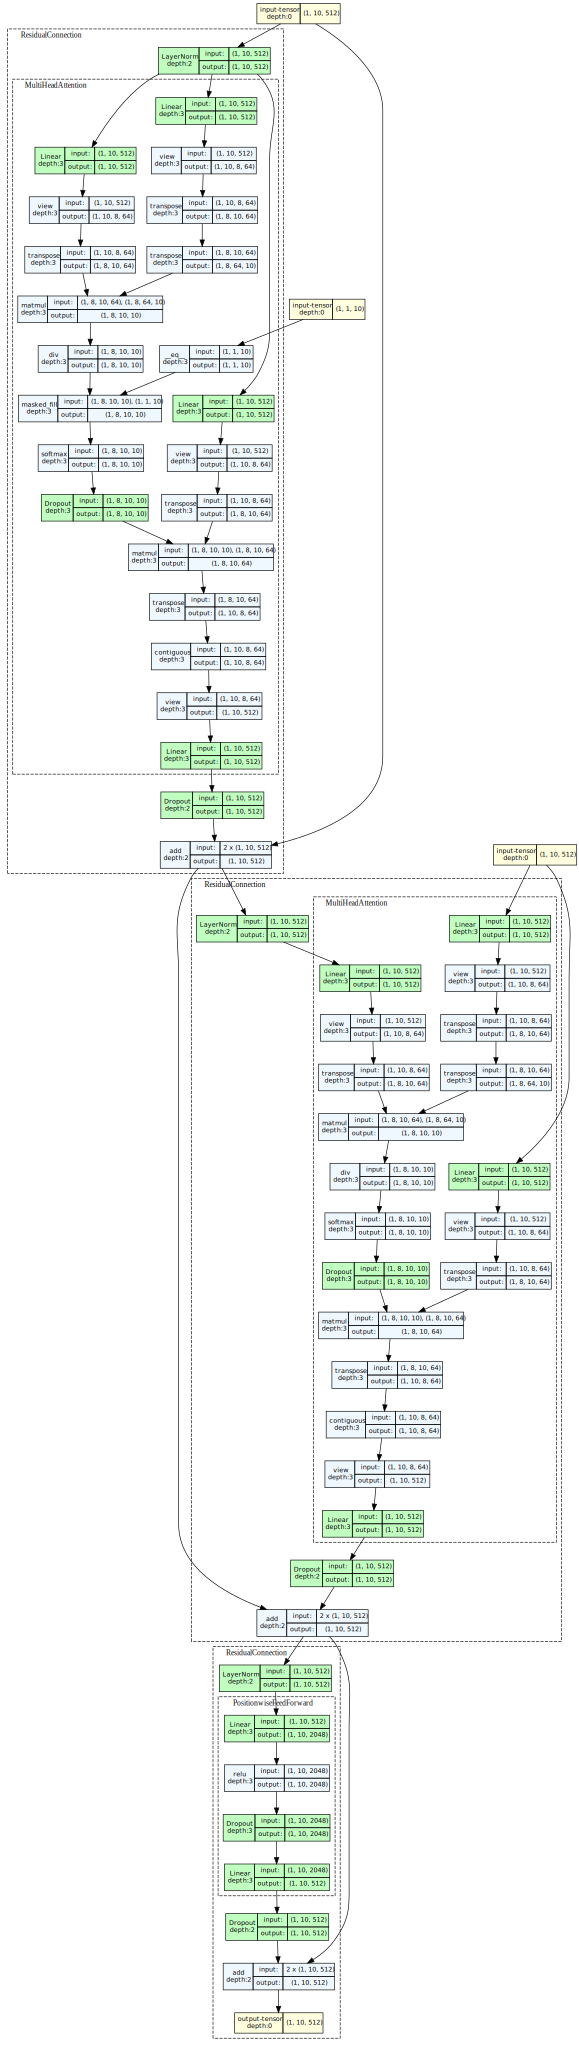

In [20]:
from torchview import draw_graph
# ============================================================
# Visualization 2: Model Architecture with torchview
# ============================================================
print("=" * 60)
print("VISUALIZATION 2: Model Architecture (torchview)")
print("=" * 60)
try:
    model_graph = draw_graph(
        decoder_layer,
        input_data=(x, m, tgt_mask, src_mask),
        graph_dir='TB', # Horizontal layout
                        # 'TB'	Top to Bottom	Vertical (default)
                        # 'LR'	Left to Right	Horizontal
                        # 'BT'	Bottom to Top	Vertical (reversed)
                        # 'RL'	Right to Left	Horizontal (reversed)
        expand_nested=True,
        graph_name='Encoder layer',
        save_graph=True,
        filename='encoder_layer_arch',
        directory='.'
    )
    
    print("✓ Architecture diagram saved as 'encoder_layer_arch.png'")
    print(f"✓ Model graph object created")
    
    # Display visual graph
    display(model_graph.visual_graph)
    
except Exception as e:
    print(f"✗ Failed to generate architecture diagram: {e}")

print()

In [28]:
class Decoder(nn.Module):
    def __init__(self, layer, N):
        """Decoder stack with N layers"""
        super(Decoder, self).__init__()
        self.layers = nn.ModuleList([copy.deepcopy(layer) for _ in range(N)])
        self.norm = LayerNorm(layer.d_model)

    def forward(self, x, memory, tgt_mask, src_mask):
        print(f"+DECODER:x shape:{x.shape} memory shape:{memory.shape} tgt_mask shape:{tgt_mask.shape if tgt_mask else 'None'} src_mask shape:{src_mask.shape}")
        for layer in self.layers:
            x = layer(x, memory, tgt_mask, src_mask)
        output_decoder = self.norm(x)
        print(f"-DECODER:output shape:{output_decoder.shape}")
        return output_decoder

In [29]:
# Decoder layers: Multi-head self-attention + cross-attention + feed-forward
batch_size, seq_len,  d_model, h , d_ff, dropout, N = 1, 10, 512, 8, 2048, 0.1, 2
x = torch.randn(batch_size, seq_len, d_model)

src_mask = torch.randn(batch_size, seq_len).unsqueeze(-2)
tgt_mask = None

# assume m as the encoder output for cross-attention
m = torch.randn(batch_size, seq_len, d_model)

# build the decoder layer
self_attn = MultiHeadAttention(d_model, h)
cross_attn = MultiHeadAttention(d_model, h)
ffn = PositionwiseFeedForward(d_model, d_ff)
decoder_layer = DecoderLayer(d_model, self_attn, cross_attn, ffn, dropout)
decorder = Decoder(decoder_layer, N)

decoder_output = decorder(x, m, tgt_mask, src_mask)

+DECODER:x shape:torch.Size([1, 10, 512]) memory shape:torch.Size([1, 10, 512]) tgt_mask shape:None src_mask shape:torch.Size([1, 1, 10])
+DC_LAYER:x.shape=torch.Size([1, 10, 512]), memory.shape=torch.Size([1, 10, 512])
+RC: x.shape=torch.Size([1, 10, 512])
+LN x shape:torch.Size([1, 10, 512])
	LN: mean shape: torch.Size([1, 10, 1])
	LN: std shape: torch.Size([1, 10, 1])
-LN output shape:torch.Size([1, 10, 512])
+MHA:[1, 10, 512]
+AT: q/k/v shapes: torch.Size([1, 8, 10, 64])
	scores shape: torch.Size([1, 8, 10, 10])
	attn shape: torch.Size([1, 8, 10, 10])
-AT: output shape:torch.Size([1, 8, 10, 64])
-MHA: output shape:[1, 10, 512]
-RC: output shape: torch.Size([1, 10, 512])
+RC: x.shape=torch.Size([1, 10, 512])
+LN x shape:torch.Size([1, 10, 512])
	LN: mean shape: torch.Size([1, 10, 1])
	LN: std shape: torch.Size([1, 10, 1])
-LN output shape:torch.Size([1, 10, 512])
+MHA:[1, 10, 512]
+AT: q/k/v shapes: torch.Size([1, 8, 10, 64])
	scores shape: torch.Size([1, 8, 10, 10])
	attn shape: to

VISUALIZATION 2: Model Architecture (torchview)
+DECODER:x shape:torch.Size([1, 10, 512]) memory shape:torch.Size([1, 10, 512]) tgt_mask shape:None src_mask shape:torch.Size([1, 1, 10])
+DC_LAYER:x.shape=torch.Size([1, 10, 512]), memory.shape=torch.Size([1, 10, 512])
+RC: x.shape=torch.Size([1, 10, 512])
+LN x shape:torch.Size([1, 10, 512])
	LN: mean shape: torch.Size([1, 10, 1])
	LN: std shape: torch.Size([1, 10, 1])
-LN output shape:torch.Size([1, 10, 512])
+MHA:[1, 10, 512]
+AT: q/k/v shapes: torch.Size([1, 8, 10, 64])
	scores shape: torch.Size([1, 8, 10, 10])
	attn shape: torch.Size([1, 8, 10, 10])
-AT: output shape:torch.Size([1, 8, 10, 64])
-MHA: output shape:[1, 10, 512]
-RC: output shape: torch.Size([1, 10, 512])
+RC: x.shape=torch.Size([1, 10, 512])
+LN x shape:torch.Size([1, 10, 512])
	LN: mean shape: torch.Size([1, 10, 1])
	LN: std shape: torch.Size([1, 10, 1])
-LN output shape:torch.Size([1, 10, 512])
+MHA:[1, 10, 512]
+AT: q/k/v shapes: torch.Size([1, 8, 10, 64])
	scores s

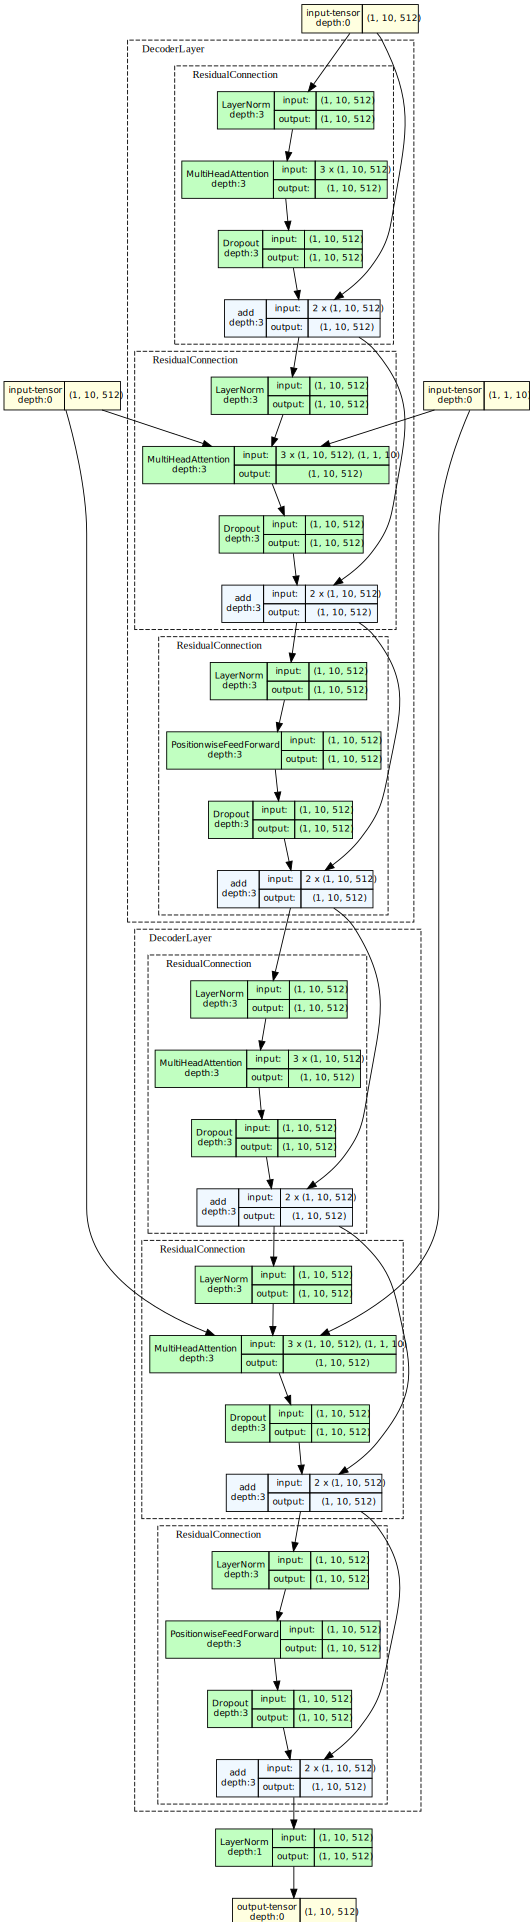

In [30]:
from torchview import draw_graph
# ============================================================
# Visualization 2: Model Architecture with torchview
# ============================================================
print("=" * 60)
print("VISUALIZATION 2: Model Architecture (torchview)")
print("=" * 60)
try:
    model_graph = draw_graph(
        decorder,
        input_data=(x, m, tgt_mask, src_mask),
        graph_dir='TB', # Horizontal layout
                        # 'TB'	Top to Bottom	Vertical (default)
                        # 'LR'	Left to Right	Horizontal
                        # 'BT'	Bottom to Top	Vertical (reversed)
                        # 'RL'	Right to Left	Horizontal (reversed)
        expand_nested=True,
        graph_name='Encoder layer',
        save_graph=True,
        filename='encoder_layer_arch',
        directory='.'
    )
    
    print("✓ Architecture diagram saved as 'encoder_layer_arch.png'")
    print(f"✓ Model graph object created")
    
    # Display visual graph
    display(model_graph.visual_graph)
    
except Exception as e:
    print(f"✗ Failed to generate architecture diagram: {e}")

print()